In [1]:
import numpy as np
import gamry_parser
import glob
from pathlib import Path
import os
import re
from scipy.optimize import differential_evolution
from impedance.models.circuits import CustomCircuit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import impedance.models.circuits.fitting as fitting


In [10]:
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data\8-HQ")
patterns = ['*_1H.DTA']
file_list = []

for p in patterns:
    file_list.extend(list(main_dir.rglob(p)))
file_list.sort(key=lambda x: int(re.search(r'(\d+)H', x.name).group(1)))
    
all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    original_eis_data = {
        'name': filename.stem,
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Z_data':data['Zreal'].values + 1j*data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values,
        'circuit':None,
        'Z_fit':None,
        'chi_sq': None
    }

    eis_data = {
        'name': filename.stem,
        'Zreal':None,
        'Zimag':None,
        'Zmod':None,
        'Zphz':None,
        'Z_data':None,
        'Freq':None,
        'circuit':None,
        'Z_fit':None,
        'chi_sq': None
    }
    
    all_datasets.append({"eis_data":eis_data, "original_eis_data":original_eis_data})

In [3]:
circuits_data = {
    '1RC_W': {
        'string': 'R0-p(R1-W1,CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1e-5, 1e7), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3]
    },
    '1RC_Wo': {
        'string': 'R0-p(R1-Wo1,CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1e-5, 1e7), (1e-6, 1e4), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,4]
    },
    '1RC_Ws': {
        'string': 'R0-p(R1-Ws1,CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1e-5, 1e7), (1e-6, 1e4), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,4]
    },
    '1RC': {
        'string': 'R0-p(R1,CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e12), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2]
    },
    '2RC_W': {
        'string': 'R0-p(R1-p(R2-W2,CPE2),CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1, 1e8), (1e-5, 1e7), (1e-11, 1e-3), (0.5, 1), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,4,6]
    },
    '2RC_Wo': {
        'string': 'R0-p(R1-p(R2-Wo2,CPE2),CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1, 1e8), (1e-5, 1e7), (1e-6, 1e4), (1e-11, 1e-3), (0.5, 1), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,4,5,7]
    },
    '2RC_Ws': {
        'string': 'R0-p(R1-p(R2-Ws2,CPE2),CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1, 1e8), (1e-5, 1e7), (1e-6, 1e4), (1e-11, 1e-3), (0.5, 1), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,4,5,7]
    },
    '2RC': {
        'string': 'R0-p(R1-p(R2,CPE2),CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1, 1e12), (1e-11, 1e-3), (0.5, 1), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,5]
    },
    '3RC': {
        'string': 'R0-p(R1-p(R2-p(R3,CPE3),CPE2),CPE1)',
        'bounds': [(1e-3, 1e3), (1, 1e8), (1, 1e8), (1, 1e8), (1e-11, 1e-3), (0.5, 1), (1e-11, 1e-3), (0.5, 1), (1e-11, 1e-3), (0.5, 1)],
        'log_indices': [0,1,2,3,4,6,8]
    },

}


choice_1 = '1RC'
choice = choice_1

circuit_string = circuits_data[choice_1]['string']
bounds = circuits_data[choice_1]['bounds']
log_indices = circuits_data[choice_1]['log_indices']
data_key = 'original_eis_data'


In [4]:
def parameter_guesser(all_datasets, circuit_string, bounds, log_indices, data_key):
    # Ensure log_indices is a numpy array for correct "fancy indexing"
    log_idx_arr = np.array(log_indices, dtype=int)

    for i, dataset in enumerate(all_datasets):
        freq = dataset[data_key]['Freq']
        z_data = dataset[data_key]['Z_data']

        # 1. Define the objective function for Differential Evolution
        def objective_function(params):
            try:
                # params is passed as a numpy array by the optimizer
                real_params = np.array(params, copy=True)
                
                # Convert only the logged parameters back to linear scale
                real_params[log_idx_arr] = 10**real_params[log_idx_arr]
                
                circuit = CustomCircuit(circuit_string, initial_guess=real_params)
                z_fit = circuit.predict(freq)
                
                # Standard EIS objective: normalized sum of squared residuals
                res = np.sum(np.abs(z_data - z_fit)**2 / np.abs(z_data)**2)
                return res
            except Exception:
                return 1e15 # Large penalty for failed fits

        # 2. Prepare the log-transformed bounds for global optimization
        log_bounds = [
            (np.log10(low), np.log10(high)) if idx in log_indices else (low, high)
            for idx, (low, high) in enumerate(bounds)
        ]

        # 3. Perform Global Optimization (Differential Evolution)
        de_parameters = differential_evolution(
            objective_function, 
            log_bounds,
            strategy='best1bin',
            popsize=50,
            tol=0.001,
            mutation=(0.5, 1),
            recombination=0.7
        )

        # 4. Process the global result back to linear scale
        de_results = np.array(de_parameters.x, copy=True)
        de_results[log_idx_arr] = 10**de_results[log_idx_arr]

        # 5. Local Refinement (Polishing the fit in linear space)
        lower_bounds, upper_bounds = zip(*bounds)
        fit_bounds = (list(lower_bounds), list(upper_bounds))
        
        circuit = CustomCircuit(circuit_string, initial_guess=de_results)
        circuit.fit(
            freq, 
            z_data,
            bounds=fit_bounds,
            weight_by_modulus=True,
            global_opt=False  # Only local search since DE already did the heavy lifting
        )

        # 6. Final Results and Error Calculation
        z_fit = circuit.predict(freq)

        def chi_squared(z_d, z_f, n_params):
            n_points = len(z_d)
            # Degrees of freedom: total points (real+imag) - parameters
            # Note: Since Z is complex, n_points technically counts as 2*len(z_d)
            dof = (2 * n_points) - n_params
            
            weight = np.abs(z_d)**2
            residuals = (np.abs(z_d - z_f)**2) / weight
            return np.sum(residuals) / dof

        # Calculate Chi-Squared using the total number of parameters in bounds
        chi_result = chi_squared(z_data, z_fit, len(bounds))
            
        # Store results back in the dataset
        dataset[data_key]['circuit'] = circuit
        dataset[data_key]['Z_fit'] = z_fit
        dataset[data_key]['chi_sq'] = chi_result
        
        
    return all_datasets


In [5]:
all_datasets = parameter_guesser(all_datasets, circuit_string, bounds, log_indices, data_key)

C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")


In [6]:
def plotter(all_datasets, data_key, choice):
    for dataset in all_datasets:
        name = dataset[data_key]['name']
        freq = dataset[data_key]['Freq']
        z_data = dataset[data_key]['Z_data']
        z_fit = dataset[data_key]['Z_fit']

        fig = plt.figure(figsize=(12, 10))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1.2], width_ratios=[1, 1])
        
        ax1 = fig.add_subplot(gs[0, :]) 
        
        ax1.plot(z_data.real, -z_data.imag, 'o', label='Experimental Data', markersize=5, alpha=0.6)
        ax1.plot(z_fit.real, -z_fit.imag, 'r-', label='10-Parameter Fit', linewidth=2)
        
        ax1.set_aspect('equal', adjustable='box')
        limit_max = max(z_data.real.max(), -z_data.imag.max())
        limit_min = min(z_data.real.min(), -z_data.imag.min())
        ax1.set_ylim(1.1*limit_min, 1.1*limit_max)
        ax1.set_xlim(1.1*limit_min, 1.1*limit_max)
        
        ax1.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_title("Nyquist Plot")
        ax1.legend()
        ax1.ticklabel_format(style='sci', axis='both',scilimits=(0,0), useMathText=True)
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        ax2 = fig.add_subplot(gs[1, 0]) 
        
        ax2.loglog(freq, abs(z_data), 'o', markersize=4, alpha=0.6)
        ax2.loglog(freq, abs(z_fit), 'r-', linewidth=1.5)
        ax2.set_xlabel("Frequency (Hz)")
        ax2.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
        ax2.set_title("Bode Modulus")
        ax2.grid(True, which="both", linestyle='--', alpha=0.4)
        
        ax3 = fig.add_subplot(gs[1, 1]) 
        
        ax3.semilogx(freq, np.angle(z_data, deg=True), 'o', markersize=4, alpha=0.6)
        ax3.semilogx(freq, np.angle(z_fit, deg=True), 'r-', linewidth=1.5)
        ax3.set_xlabel("Frequency (Hz)")
        ax3.set_ylabel(r"Phase Angle (deg)")
        ax3.set_title("Bode Phase")
        ax3.grid(True, which="both", linestyle='--', alpha=0.4)
        
        plt.tight_layout()
        plt.savefig(f"plots_{name}_{choice}.pdf")
        plt.show()
    return None

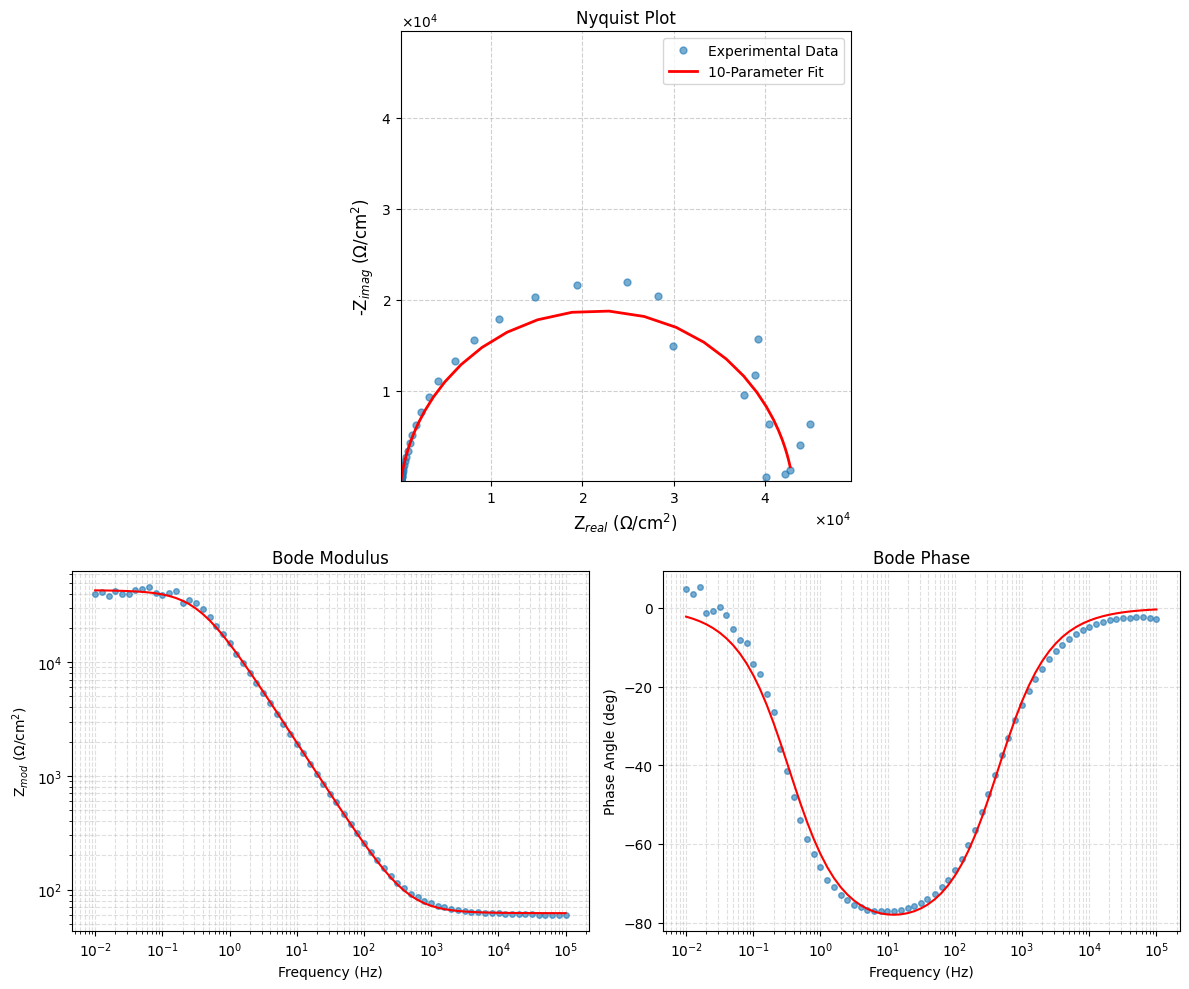

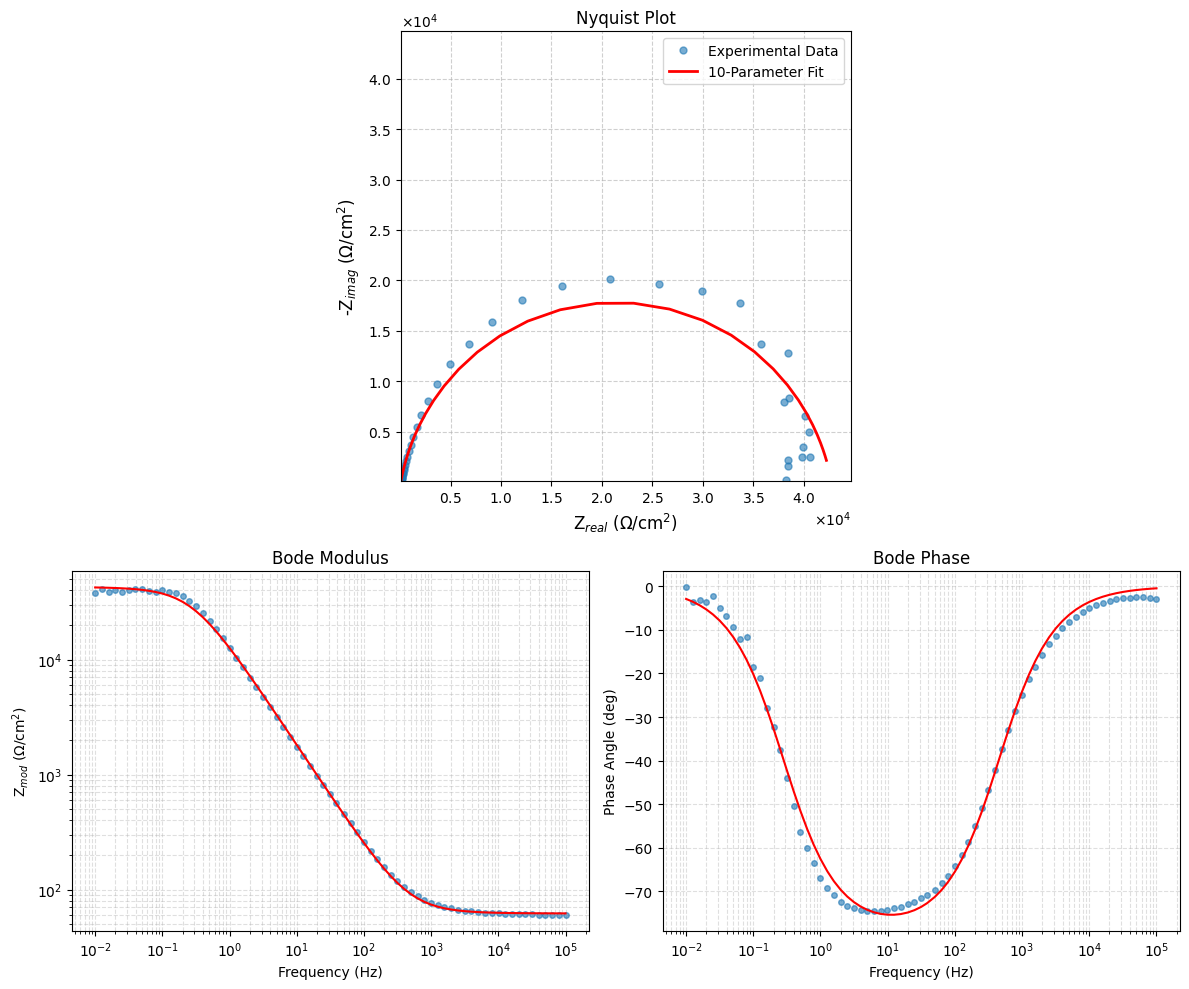

In [7]:
plotter(all_datasets, 'original_eis_data', choice)

In [17]:
end_points_to_drop = 0
freq_condition_max = 1e4
freq_condition_min = 1e-1

def data_to_keep(all_datasets,end_points_to_drop, freq_condition_max, freq_condition_min):

    for dataset in all_datasets:
        freqs = np.array(dataset['original_eis_data']['Freq'])

        combined_condition = (freqs <= freq_condition_max) & (freqs >= freq_condition_min)
        
        keys = ['Freq', 'Zreal', 'Zimag', 'Zmod', 'Zphz', 'Z_data']

        for key in keys:
            if end_points_to_drop > 0:
                dataset['eis_data'][key] = dataset['original_eis_data'][key][combined_condition]
                dataset['eis_data'][key] = dataset['eis_data'][key][:-end_points_to_drop]
            else:
                dataset['eis_data'][key] = dataset['original_eis_data'][key][combined_condition]
                
    return all_datasets

all_datasets = data_to_keep(all_datasets, end_points_to_drop, freq_condition_max, freq_condition_min)

C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")


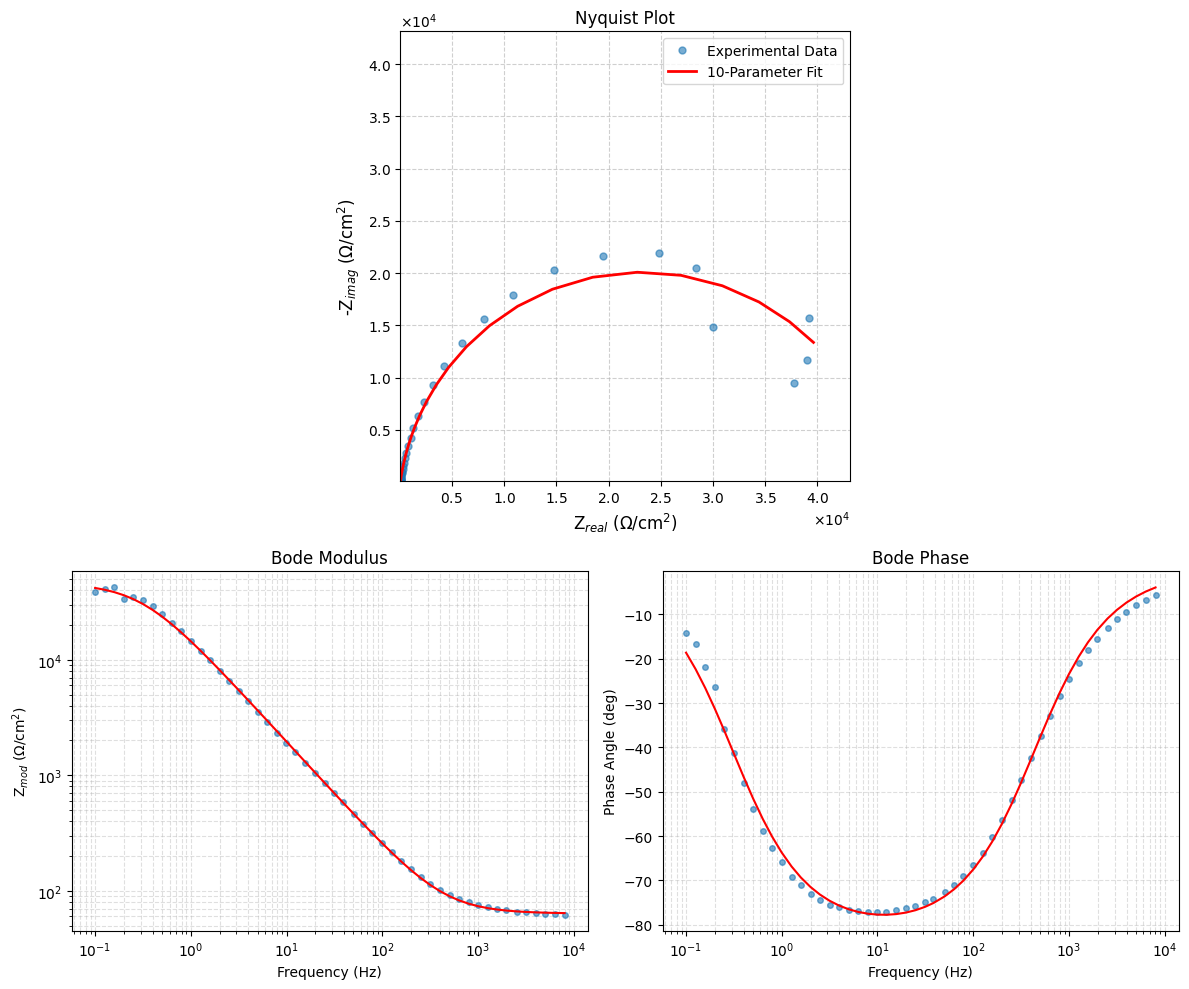

In [18]:
choice_2 = '2RC'
choice = choice_2
data_key = 'eis_data'
circuit_string = circuits_data[choice_2]['string']
bounds = circuits_data[choice_2]['bounds']
log_indices = circuits_data[choice_2]['log_indices']

all_datasets = parameter_guesser(all_datasets, circuit_string, bounds, log_indices, 'eis_data')
plotter(all_datasets, 'eis_data', choice)

In [19]:
print(all_datasets[0]['eis_data']['circuit'])


Circuit string: R0-p(R1-p(R2,CPE2),CPE1)
Fit: True

Initial guesses:
     R0 = 6.33e+01 [Ohm]
     R1 = 4.63e+04 [Ohm]
     R2 = 1.32e+00 [Ohm]
  CPE2_0 = 2.94e-07 [Ohm^-1 sec^a]
  CPE2_1 = 7.12e-01 []
  CPE1_0 = 1.18e-05 [Ohm^-1 sec^a]
  CPE1_1 = 9.10e-01 []

Fit parameters:
     R0 = 6.33e+01  (+/- 7.19e-01) [Ohm]
     R1 = 4.63e+04  (+/- 9.21e+05) [Ohm]
     R2 = 1.32e+00  (+/- 9.21e+05) [Ohm]
  CPE2_0 = 2.94e-07  (+/- 1.86e+03) [Ohm^-1 sec^a]
  CPE2_1 = 7.12e-01  (+/- 2.90e-09) []
  CPE1_0 = 1.18e-05  (+/- 1.21e-06) [Ohm^-1 sec^a]
  CPE1_1 = 9.10e-01  (+/- 1.08e-02) []



In [13]:
def generate_combined_eis_report(all_datasets, circuit_string, bounds, choice, data_key, end_points_to_drop, freq_condition_max, freq_condition_min):
    # 1. Extract parameter matches
    first_text = str(all_datasets[0][data_key]['circuit'])
    param_pattern = r"([A-Z0-9_]+)\s+=\s+([0-9.e+-]+)\s+\(\+/-\s+([0-9.e+-]+)\)\s+\[(.*?)\]"
    
    if "Fit parameters:" in first_text:
        fit_section = first_text.split("Fit parameters:")[1]
        matches = re.findall(param_pattern, fit_section)
    else:
        matches = re.findall(param_pattern, first_text)

    # 2. Build Header - Added Bounds column
    header = r"\textbf{Element} & \textbf{Unit} & \textbf{Bounds}"
    column_setup = "|l|c|c|" # Added extra 'c' for bounds
    for dataset in all_datasets:
        clean_file_name = dataset[data_key]['name'].replace("_", r"\_")
        header += f" & \\textbf{{{clean_file_name}}}"
        column_setup += "c|"

    # 3. Build Table Rows
    table_rows = ""
    # We use enumerate to track the index for the 'bounds' list
    for idx, (p_name, _, _, p_unit) in enumerate(matches):
        # --- DYNAMIC MAPPING ---
        if "CPE" in p_name:
            num = re.search(r'CPE(\d+)', p_name).group(1) if re.search(r'CPE(\d+)', p_name) else ""
            display_name = f"Q_{{{num}}}" if p_name.endswith("_0") else f"n_{{{num}}}"
        elif p_name.startswith("L"):
            num = re.search(r'L(\d+)', p_name).group(1) if re.search(r'L(\d+)', p_name) else ""
            display_name = f"L_{{{num}}}"
        elif p_name[0].isdigit(): 
            p_idx, p_type = p_name.split("_")
            display_name = rf"W_{{{p_idx},R}}" if p_type == "0" else rf"W_{{{p_idx},\tau}}"
        elif p_name.startswith("R"):
            num = re.search(r'R(\d+)', p_name).group(1) if re.search(r'R(\d+)', p_name) else ""
            display_name = f"R_{{{num}}}"
        else:
            display_name = p_name

        clean_p_name = f"${display_name}$"
        
        # Format Units
        clean_unit = p_unit.replace("Ohm", r"$\Omega$").replace("^-1", r"$^{-1}$").replace("^a", r"$^{a}$")
        if not clean_unit.strip() or clean_unit == "[]": 
            clean_unit = "-"

        # --- GET BOUNDS ---
        if idx < len(bounds):
            b_low, b_high = bounds[idx]
            # Formats bounds in scientific notation for consistency
            bounds_str = f"$[{b_low:.1e}, {b_high:.1e}]$"
        else:
            bounds_str = "-"
            
        row_content = f"{clean_p_name} & {clean_unit} & {bounds_str}"
        
        # 4. Values and Errors
        for dataset in all_datasets:
            txt = str(dataset[data_key]['circuit'])
            m = re.search(rf"{p_name}\s+=\s+([0-9.e+-]+)\s+\(\+/-\s+([0-9.e+-]+)\)", txt)
            if m:
                val, err = m.groups()
                row_content += f" & ${float(val):.2e} \\pm {float(err):.1e}$"
            else:
                row_content += " & N/A"
        
        table_rows += rf"        {row_content} \\ \hline" + "\n"

    # 5. Chi-Squared Row - Added empty cell for Bounds column
    chi_row = r"\textbf{$\chi^2$} & - & - " 
    for dataset in all_datasets:
        chi = dataset[data_key]['chi_sq']
        chi_row += f" & ${chi:.3e}$"
    table_rows += rf"        {chi_row} \\ \hline" + "\n"

    # 6. Plot Sections
    plot_sections = ""
    for dataset in all_datasets:
        d_name = dataset[data_key]['name']
        hr_match = re.search(r'(\d+H)$', d_name)
        hr = hr_match.group(1) if hr_match else d_name
        plot_file = f"plots_{d_name.replace('.DTA', '')}_{choice}.pdf"
        
        plot_sections += r"""
\newpage
\section*{Analysis Results: """ + hr + r"""}
\begin{center}
    \includegraphics[width=0.7\textwidth]{""" + plot_file + r"""}
    \captionof{figure}{EIS Fit Results for """ + d_name.replace("_", r"\_") + r"""}
\end{center}
"""

    if data_key == 'original_eis_data':
        data_description = "original data"
    else:
        formatted_freq_max = f"{float(freq_condition_max):.0e}"
        formatted_freq_min = f"{float(freq_condition_min):.0e}"
        data_description = (
            f"altered data, first {end_points_to_drop} points removed and "
            f"points with $freq > {formatted_freq_max}$ and "
            f"$freq < {formatted_freq_min}$ removed"
        )
    
    # 7. Final Assembly
    tex_final = r"""
\documentclass[10pt]{article}
\usepackage[utf8]{inputenc}
\usepackage{graphicx}
\usepackage{amsmath, amssymb}
\usepackage{geometry}
\usepackage{caption} 
\geometry{a4paper, margin=0.5in, landscape} 

\begin{document}

\section*{Comparative EIS Kinetics Report}
\textbf{Model Structure:} \texttt{""" + circuit_string.replace("_", r"\_") + r"""} \\
\textbf{Used data:} """ + data_description + r"""

\begin{center}
""" + f"    \\includegraphics[width=0.45\\textwidth]{{{choice}.png}}" + r"""
\end{center}

\renewcommand{\arraystretch}{1.6} 
\begin{table}[h!]
    \centering
    \footnotesize
    \begin{tabular}{""" + column_setup + r"""}
        \hline
        """ + header + r""" \\ \hline
""" + table_rows + r"""
    \end{tabular}
\end{table}

""" + plot_sections + r"""

\end{document}
"""
    f_name = all_datasets[0][data_key]['name'].split('_')[2]
    hours_list = []
    
    for dataset in all_datasets:
        name = dataset[data_key]['name']
        match = re.search(r'(\d+)H$', name)
        if match:
            hours_list.append(match.group(1))

    hour_str = "H_".join(hours_list)

    with open(f"eis_report_{f_name}_{hour_str}H_{choice}.tex", "w", encoding="utf-8") as f:
        f.write(tex_final)
    
generate_combined_eis_report(all_datasets, circuit_string, bounds, choice, data_key, end_points_to_drop, freq_condition_max, freq_condition_min)

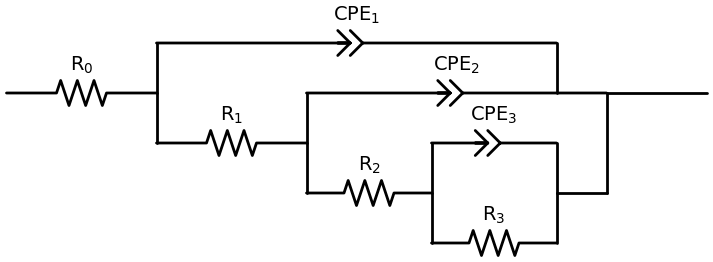

In [129]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.Resistor().right().label('R$_0$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(8).label('CPE$_1$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().label('R$_1$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(6).label('CPE$_2$')
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label('R$_2$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(2.5).label('CPE$_3$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label('R$_3$')
    d += elm.Line().up().length(1)
    d += elm.Line().right().length(1)
    d += elm.Line().up().length(2)
    d += elm.Line().right().length(2)
    d.save('3RC.png', dpi=500, transparent=True)
    
    
    